In [1]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


# Single gene-trait association plots

In [2]:
## Single gene-trait association plot
gene_name = 'LDLR'
phenotype = 'ldl_direct_int'

In [3]:
# Configuration and paths
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'
mac = 100

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)
mac
config_path = "/home/dnanexus/ukbgym/config_wgs.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records)
all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()
anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i64
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
"""missense""","""am_pathogenicity""","""#e76e5b""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",-1
"""conservation""","""gpn_score""","""#942c80""","""GPN-MSA""",-1
"""conservation""","""zooverphylop""","""#6a1c81""","""Zoonomia vertebrate PhyloP""",1
…,…,…,…,…
"""regulatory""","""promoterai_abs""","""#00A99D""","""PromoterAI abs""",1
"""regulatory""","""promoterai_under""","""#00A99D""","""PromoterAI under""",-1
"""regulatory""","""promoterai_over""","""#00A99D""","""PromoterAI over""",1


In [4]:
exp_data = pl.read_csv('/home/dnanexus/data_dir/exp_data/kircher_all_enhancers_and_promoters.tsv', separator='\t').drop(['pos']).rename({
    'locus': 'gene_name',
    'Chromosome': 'chrom',
    'variant_pos': 'pos',
}).with_columns(
    id = pl.col("chrom") + ":" + pl.col("pos").cast(pl.Utf8) + ":" + pl.col("ref") + ":" + pl.col("alt"),
).select(['id', 'gene_name', 'log2FC'])

exp_data['gene_name'].value_counts(sort=True).head(10)

gene_name,count
str,u64
"""SORT1""",1758
"""IRF6""",1734
"""MYCrs6983267""",1668
"""ZFAND3""",1647
"""MSMB""",1641
"""PKLR""",1383
"""IRF4""",1326
"""GP1BB""",1119
"""LDLR""",928


In [5]:
anno = pl.scan_parquet(f"/home/dnanexus/data_dir/genebass1e6_genes_10kb_allvars_annotated_250925.parquet").filter(pl.col('gene_name') == gene_name).collect(engine='streaming')

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

anno = (
    anno
    .select(
        set(['id', 'region', 'TSS', 'Strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
)
anno

delta_score,abexp_max,cadd_raw,zooverphylop,relative_cds_position,region,promoterai,dist_to_tss,absplice_dna_max,abexp_min,promoterai_abs,promoterai_under,Strand,am_pathogenicity,gpn_score,pangolin_score,TSS,absplice2_max,gene_length,verphylop,id,promoterai_over,gene_name,esmscoremissense
f32,f64,f32,f32,f32,str,f32,i64,f32,f64,f32,f32,cat,f32,f32,f32,i64,f32,i64,f32,str,f32,str,f32
0.0,-0.005501,0.372048,-0.12,0.0,"""ENSG00000130164""",0.0,4277,0.001,-0.005877,0.0,0.0,"""+""",0.0,0.05,0.0,11089461,0.000033,44360,-0.141,"""chr19:11093738:G:A""",0.0,"""LDLR""",0.0
0.0,-0.005501,-0.889739,-2.853,0.0,"""ENSG00000130164""",0.0,21488,0.001,-0.005877,0.0,0.0,"""+""",0.0,-0.87,0.0,11089461,0.000033,44360,-1.677,"""chr19:11110949:G:A""",0.0,"""LDLR""",0.0
0.0,0.002469,-0.0706,-1.109,0.0,"""ENSG00000130164""",0.0,48226,0.0,0.002093,0.0,0.0,"""+""",0.0,0.18,0.0,11089461,0.0,44360,-1.413,"""chr19:11137687:A:C""",0.0,"""LDLR""",0.0
0.0,-0.005229,-0.358473,-1.837,0.0,"""ENSG00000130164""",0.0,42447,0.001,-0.005605,0.0,0.0,"""+""",0.0,-1.16,0.0,11089461,0.000033,44360,-2.955,"""chr19:11131908:T:C""",0.0,"""LDLR""",0.0
0.0,-0.005501,-0.016461,-0.848,0.0,"""ENSG00000130164""",0.0,10209,0.001,-0.005877,0.0,0.0,"""+""",0.0,-1.39,0.0,11089461,0.000033,44360,0.365,"""chr19:11099670:C:G""",0.0,"""LDLR""",0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.0,null,0.0,-0.146,0.0,"""ENSG00000130164""",0.0,31791,0.0,null,0.0,0.0,"""+""",0.0,-1.46,0.0,11089461,0.0,44360,0.042,"""chr19:11121252:TGAGGATTG:T""",0.0,"""LDLR""",0.0
0.0,null,0.0,-0.146,0.0,"""ENSG00000130164""",0.0,-4494,0.0,null,0.0,0.0,"""+""",0.0,-1.46,0.0,11089461,0.0,44360,0.042,"""chr19:11084967:C:CAAAAAACA""",0.0,"""LDLR""",0.0
0.0,null,0.0,-0.146,0.0,"""ENSG00000130164""",0.0,7596,0.0,null,0.0,0.0,"""+""",0.0,-1.46,0.0,11089461,0.0,44360,0.042,"""chr19:11097057:ATT:A""",0.0,"""LDLR""",0.0


In [6]:
melted_anno = anno.unpivot(
    index=["id", "region"],
    on=existing_annos,
    variable_name="annotation",
    value_name="annotation_score"
).with_columns(
    pl.col("annotation_score").cast(pl.Float32),
    pl.col("region").cast(pl.Utf8),
)
melted_anno

id,region,annotation,annotation_score
str,str,str,f32
"""chr19:11093738:G:A""","""ENSG00000130164""","""cadd_raw""",0.372048
"""chr19:11110949:G:A""","""ENSG00000130164""","""cadd_raw""",-0.889739
"""chr19:11137687:A:C""","""ENSG00000130164""","""cadd_raw""",-0.0706
"""chr19:11131908:T:C""","""ENSG00000130164""","""cadd_raw""",-0.358473
"""chr19:11099670:C:G""","""ENSG00000130164""","""cadd_raw""",-0.016461
…,…,…,…
"""chr19:11121252:TGAGGATTG:T""","""ENSG00000130164""","""abexp_max""",null
"""chr19:11084967:C:CAAAAAACA""","""ENSG00000130164""","""abexp_max""",null
"""chr19:11097057:ATT:A""","""ENSG00000130164""","""abexp_max""",null


In [7]:
# Get phenotype data for the phenotype of interest
appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_genebass1e6_PRScorr.parquet").filter(pl.col('phenotype') == phenotype).collect(engine='streaming')

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique())

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
)

# Merge phenotype data and annotation data
pg_df = (
    appv
    .join(
        melted_anno, 
        on="id", 
        how="inner"
    )
    .join(
        anno.select(['id', 'region', 'TSS', 'Strand', 'gene_length', 'gene_name', 'dist_to_tss']), 
        on=['id', 'region'], 
        how='inner'
    )
)

# Join with experimental data
pg_df = pg_df.join(exp_data.filter(pl.col('gene_name') == gene_name), on='id', how='inner')
pg_df

id,phenotype,n_individuals,mean_pheno_value,std_pheno_value,region,annotation,annotation_score,TSS,Strand,gene_length,gene_name,dist_to_tss,gene_name_right,log2FC
str,str,u32,f32,f32,str,str,f32,i64,cat,i64,str,i64,str,f64
"""chr19:11089498:C:T""","""ldl_direct_int""",1,0.611306,null,"""ENSG00000130164""","""cadd_raw""",0.7626,11089461,"""+""",44360,"""LDLR""",37,"""LDLR""",-0.15
"""chr19:11089493:T:C""","""ldl_direct_int""",6,-0.237622,0.851583,"""ENSG00000130164""","""cadd_raw""",-0.26411,11089461,"""+""",44360,"""LDLR""",32,"""LDLR""",-0.09
"""chr19:11089524:A:T""","""ldl_direct_int""",1,0.292873,null,"""ENSG00000130164""","""cadd_raw""",0.935437,11089461,"""+""",44360,"""LDLR""",63,"""LDLR""",-0.02
"""chr19:11089365:T:C""","""ldl_direct_int""",1,1.658114,null,"""ENSG00000130164""","""cadd_raw""",0.310214,11089461,"""+""",44360,"""LDLR""",-96,"""LDLR""",0.24
"""chr19:11089474:G:A""","""ldl_direct_int""",1,0.081006,null,"""ENSG00000130164""","""cadd_raw""",0.648609,11089461,"""+""",44360,"""LDLR""",13,"""LDLR""",0.89
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr19:11089526:A:C""","""ldl_direct_int""",34,0.309885,0.94807,"""ENSG00000130164""","""abexp_max""",-0.012365,11089461,"""+""",44360,"""LDLR""",65,"""LDLR""",0.1
"""chr19:11089371:T:G""","""ldl_direct_int""",3,0.834435,1.461415,"""ENSG00000130164""","""abexp_max""",-0.011976,11089461,"""+""",44360,"""LDLR""",-90,"""LDLR""",-0.56
"""chr19:11089264:A:C""","""ldl_direct_int""",2,-0.388573,0.977376,"""ENSG00000130164""","""abexp_max""",0.002469,11089461,"""+""",44360,"""LDLR""",-197,"""LDLR""",0.05


In [8]:
pg_df['annotation'].value_counts(sort=True)

annotation,count
str,u64
"""cadd_raw""",70
"""am_pathogenicity""",70
"""esmscoremissense""",70
"""gpn_score""",70
"""zooverphylop""",70
…,…
"""promoterai_abs""",70
"""promoterai_under""",70
"""promoterai_over""",70


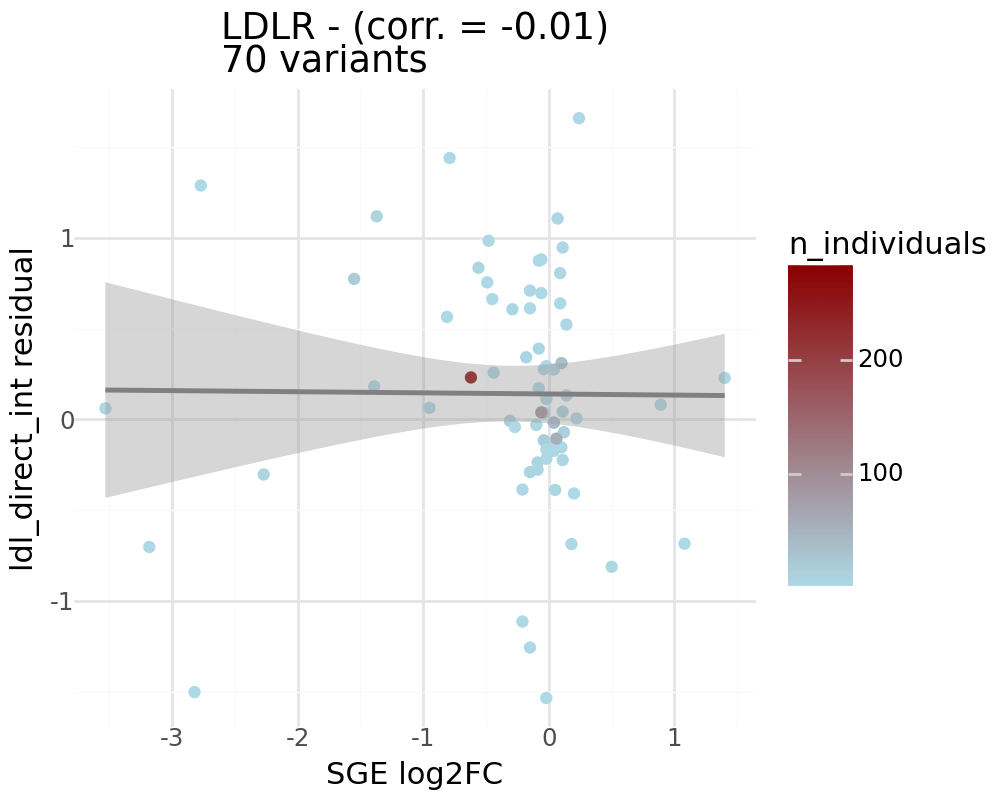

In [50]:
plot_df = pg_df[['id', 'n_individuals', 'mean_pheno_value', 'log2FC']].unique()

(
    ggplot(plot_df, aes(x='log2FC', y='mean_pheno_value', color='n_individuals')) +
    geom_point(alpha=1) +
    geom_smooth(method='lm', se=True, color='gray') +
    scale_color_gradient(low='lightblue', high='darkred') +
    theme_minimal() +
    labs(
        x="SGE log2FC",
        y=f"{phenotype} residual",
        title=f"{gene_name} - (corr. = {plot_df.select(pl.corr('log2FC', 'mean_pheno_value')).to_series()[0]:.2f})\n{plot_df.shape[0]} variants"
    ) +
    theme(figure_size=(5, 4))
)

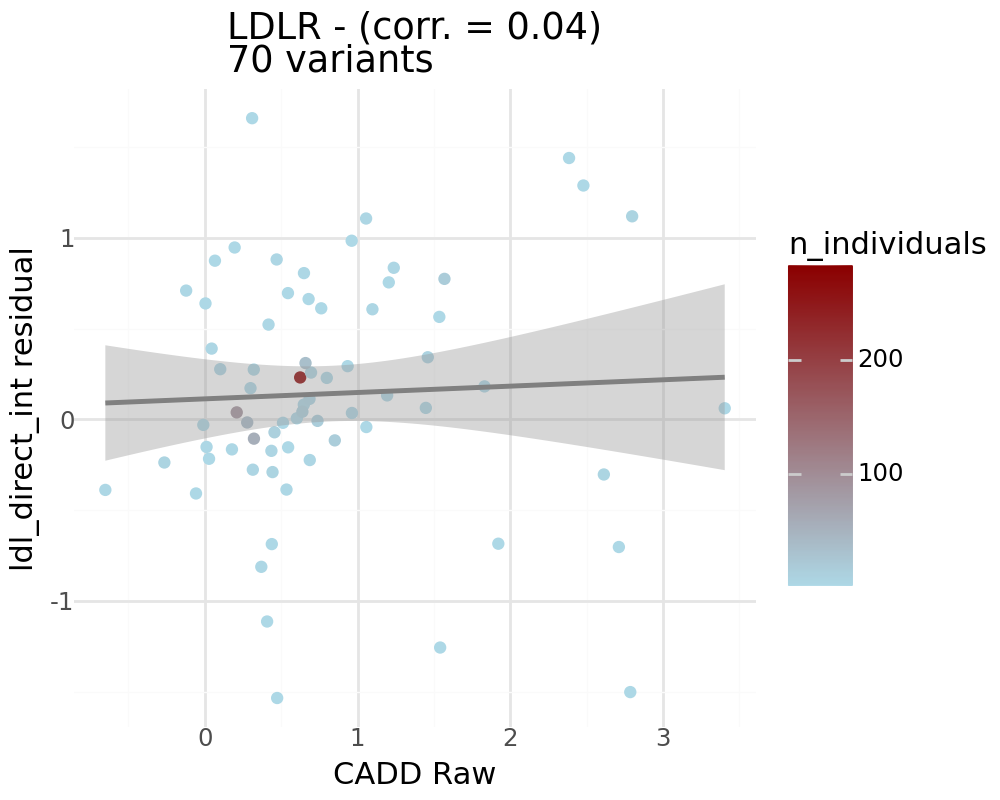

In [47]:
annotation = 'cadd_raw'
anno_label = anno_config_df.filter(pl.col('annotation') == annotation)['label'].item()

plot_df = (
    pg_df
    .filter(
        # (pl.col('dist_to_tss') >= -50) &
        # (pl.col('dist_to_tss') <= 0) &
        (pl.col('annotation') == annotation)
    )
)

(
    ggplot(plot_df, aes(x='annotation_score', y='mean_pheno_value', color='n_individuals')) +
    geom_point(alpha=1) +
    geom_smooth(method='lm', se=True, color='gray') +
    scale_color_gradient(low='lightblue', high='darkred') +
    theme_minimal() +
    labs(
        x=f"{anno_label}",
        y=f"{phenotype} residual",
        title=f"{gene_name} - (corr. = {plot_df.select(pl.corr('annotation_score', 'mean_pheno_value')).to_series()[0]:.2f})\n{plot_df.shape[0]} variants"
    ) +
    theme(figure_size=(5, 4))
)

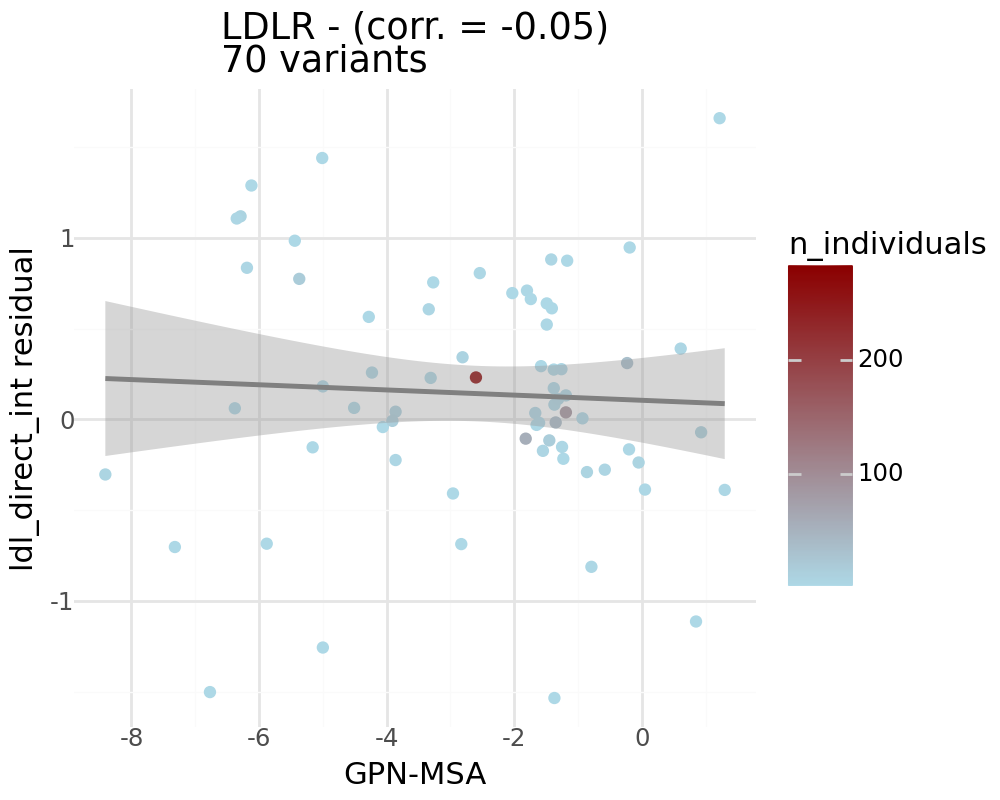

In [49]:
annotation = 'gpn_score'
anno_label = anno_config_df.filter(pl.col('annotation') == annotation)['label'].item()

plot_df = (
    pg_df
    .filter(
        # (pl.col('dist_to_tss') >= -50) &
        # (pl.col('dist_to_tss') <= 0) &
        (pl.col('annotation') == annotation)
    )
)

(
    ggplot(plot_df, aes(x='annotation_score', y='mean_pheno_value', color='n_individuals')) +
    geom_point(alpha=1) +
    geom_smooth(method='lm', se=True, color='gray') +
    scale_color_gradient(low='lightblue', high='darkred') +
    theme_minimal() +
    labs(
        x=f"{anno_label}",
        y=f"{phenotype} residual",
        title=f"{gene_name} - (corr. = {plot_df.select(pl.corr('annotation_score', 'mean_pheno_value')).to_series()[0]:.2f})\n{plot_df.shape[0]} variants"
    ) +
    theme(figure_size=(5, 4))
)

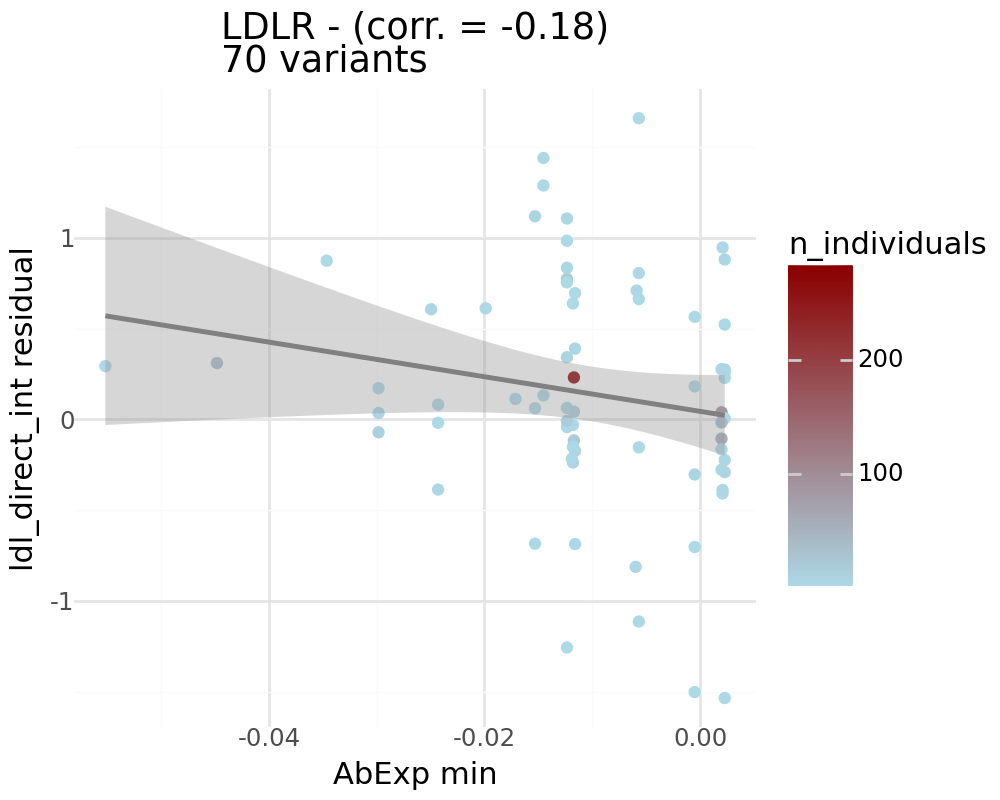

In [48]:
annotation = 'abexp_min'
anno_label = anno_config_df.filter(pl.col('annotation') == annotation)['label'].item()

plot_df = (
    pg_df
    .filter(
        # (pl.col('dist_to_tss') >= -50) &
        # (pl.col('dist_to_tss') <= 0) &
        (pl.col('annotation') == annotation)
    )
)

(
    ggplot(plot_df, aes(x='annotation_score', y='mean_pheno_value', color='n_individuals')) +
    geom_point(alpha=1) +
    geom_smooth(method='lm', se=True, color='gray') +
    scale_color_gradient(low='lightblue', high='darkred') +
    theme_minimal() +
    labs(
        x=f"{anno_label}",
        y=f"{phenotype} residual",
        title=f"{gene_name} - (corr. = {plot_df.select(pl.corr('annotation_score', 'mean_pheno_value')).to_series()[0]:.2f})\n{plot_df.shape[0]} variants"
    ) +
    theme(figure_size=(5, 4))
)

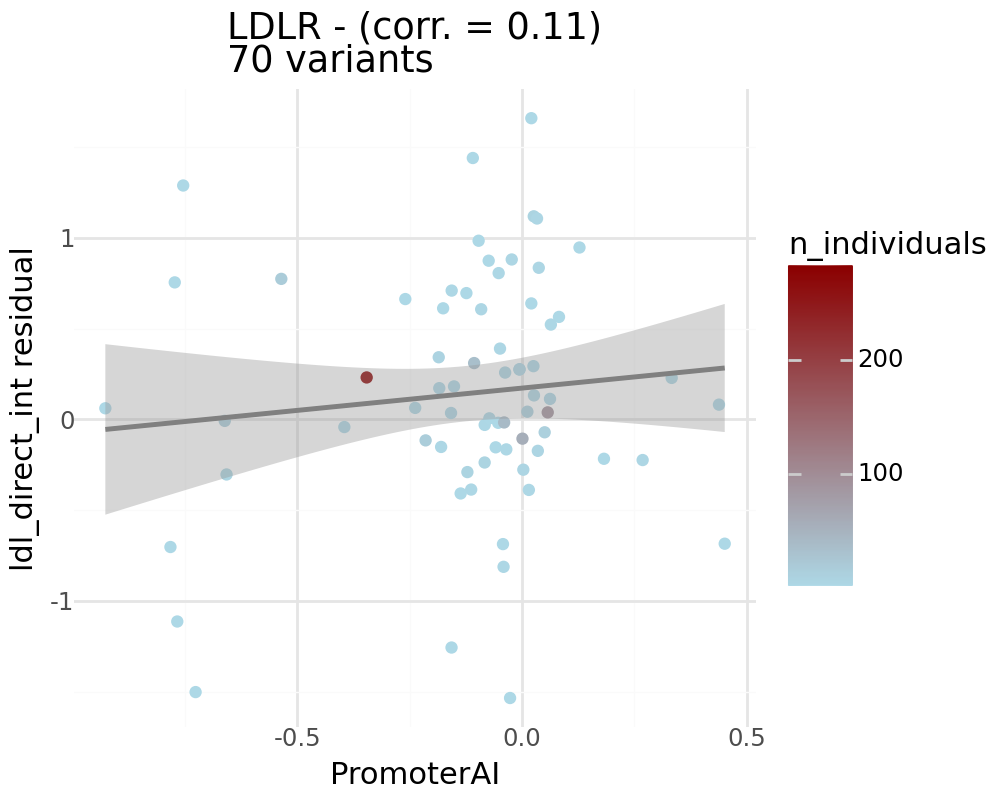

In [51]:
annotation = 'promoterai'
anno_label = anno_config_df.filter(pl.col('annotation') == annotation)['label'].item()

plot_df = (
    pg_df
    .filter(
        # (pl.col('dist_to_tss') >= -50) &
        # (pl.col('dist_to_tss') <= 0) &
        (pl.col('annotation') == annotation)
    )
)

(
    ggplot(plot_df, aes(x='annotation_score', y='mean_pheno_value', color='n_individuals')) +
    geom_point(alpha=1) +
    geom_smooth(method='lm', se=True, color='gray') +
    scale_color_gradient(low='lightblue', high='darkred') +
    theme_minimal() +
    labs(
        x=f"{anno_label}",
        y=f"{phenotype} residual",
        title=f"{gene_name} - (corr. = {plot_df.select(pl.corr('annotation_score', 'mean_pheno_value')).to_series()[0]:.2f})\n{plot_df.shape[0]} variants"
    ) +
    theme(figure_size=(5, 4))
)